In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

# !pip3 install pyramid-arima


In [11]:
 !pip3 install pyramid-arima
warnings.filterwarnings("ignore")

  Using cached pyramid-arima-0.8.1.tar.gz (515 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached cython-3.2.4-cp313-cp313-win_amd64.whl.metadata (7.7 kB)
Using cached cython-3.2.4-cp313-cp313-win_amd64.whl (2.8 MB)
  Running setup.py clean for pyramid-arima
Failed to build pyramid-arima


  DEPRECATION: Building 'pyramid-arima' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pyramid-arima'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [29 lines of output]
  Partial import of pyramid during the build process.
  
  Requirements: ['Cython>=0.23\nnumpy>=1.10\nscipy>=0.9\nscikit-learn>=0.17\npandas>=0.19\nstatsmodels>=0.9.0\n']
  Adding extra setuptools args
  Traceback (most recent call last):
    File "C:\Users\chaud\AppData\Local\Temp\pip-install-3cye8svt\pyramid-arima_6e4b4e6494dc4043b2f7a421ce32fd5d\setup.py", line 225, in do_setup
      fr

# Import Data
df = pd.read_csv('https://github.com/selva86/datasets/raw/master/AirPassengers.csv')

In [5]:
df = pd.read_csv('https://github.com/selva86/datasets/raw/master/AirPassengers.csv')
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [12]:
import os 
os.chdir(r"C:\Users\chaud\Downloads\AirPassengers.csv")

NotADirectoryError: [WinError 267] The directory name is invalid: 'C:\\Users\\chaud\\Downloads\\AirPassengers.csv'

In [9]:
df = pd.read_csv('AirPassengers.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'AirPassengers.csv'

In [ ]:
df

<AxesSubplot:xlabel='date'>

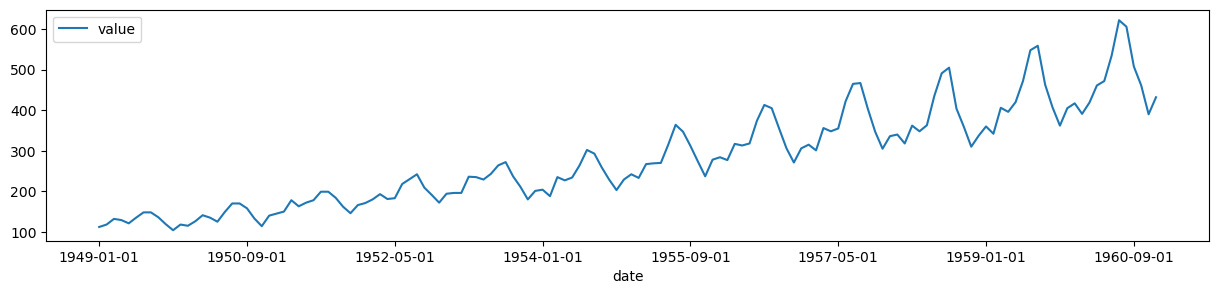

In [5]:
df.plot.line(x = 'date',y = 'value',figsize=(15,3))

# Stationary  -- ADF Test 

* H0 : - The data is  non-stationary
* H1 : - The data is  stationary

* Alpha = 0.05 


In [6]:
from statsmodels.tsa.stattools import adfuller
dftest = adfuller(df['value'])
dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
dfoutput

Test Statistic                   0.815369
p-value                          0.991880
#lags used                      13.000000
number of observations used    130.000000
dtype: float64

* we do not Reject Ho
* The data is  non-stationary

# Differencing  ( d )

In [ ]:
from matplotlib import pyplot

diff = df.value.diff()
pyplot.plot(diff)
pyplot.show()

In [7]:
df['diff_1'] = df['value'].diff()
df['diff_2'] = df['diff_1'].diff()
df

,date,value,diff_1,diff_2
0,1949-01-01,112,NaN,NaN
1,1949-02-01,118,6.0,NaN
2,1949-03-01,132,14.0,8.0
3,1949-04-01,129,-3.0,-17.0
4,1949-05-01,121,-8.0,-5.0
...,...,...,...,...
139,1960-08-01,606,-16.0,-103.0
140,1960-09-01,508,-98.0,-82.0
141,1960-10-01,461,-47.0,51.0
142,1960-11-01,390,-71.0,-24.0


In [8]:
import numpy as np
np.var(df)  # d = 1

value     14291.973331
diff_1     1131.384029
diff_2     1577.287840
dtype: float64

In [9]:
from statsmodels.tsa.stattools import adfuller
print("Observations of Dickey-fuller test")
dftest = adfuller(df.diff_1.loc[1:,])
dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
dfoutput

Observations of Dickey-fuller test


Test Statistic                  -2.829267
p-value                          0.054213
#lags used                      12.000000
number of observations used    130.000000
dtype: float64

* We Reject Ho
* The data is stationary

# ACF & PACF Plot

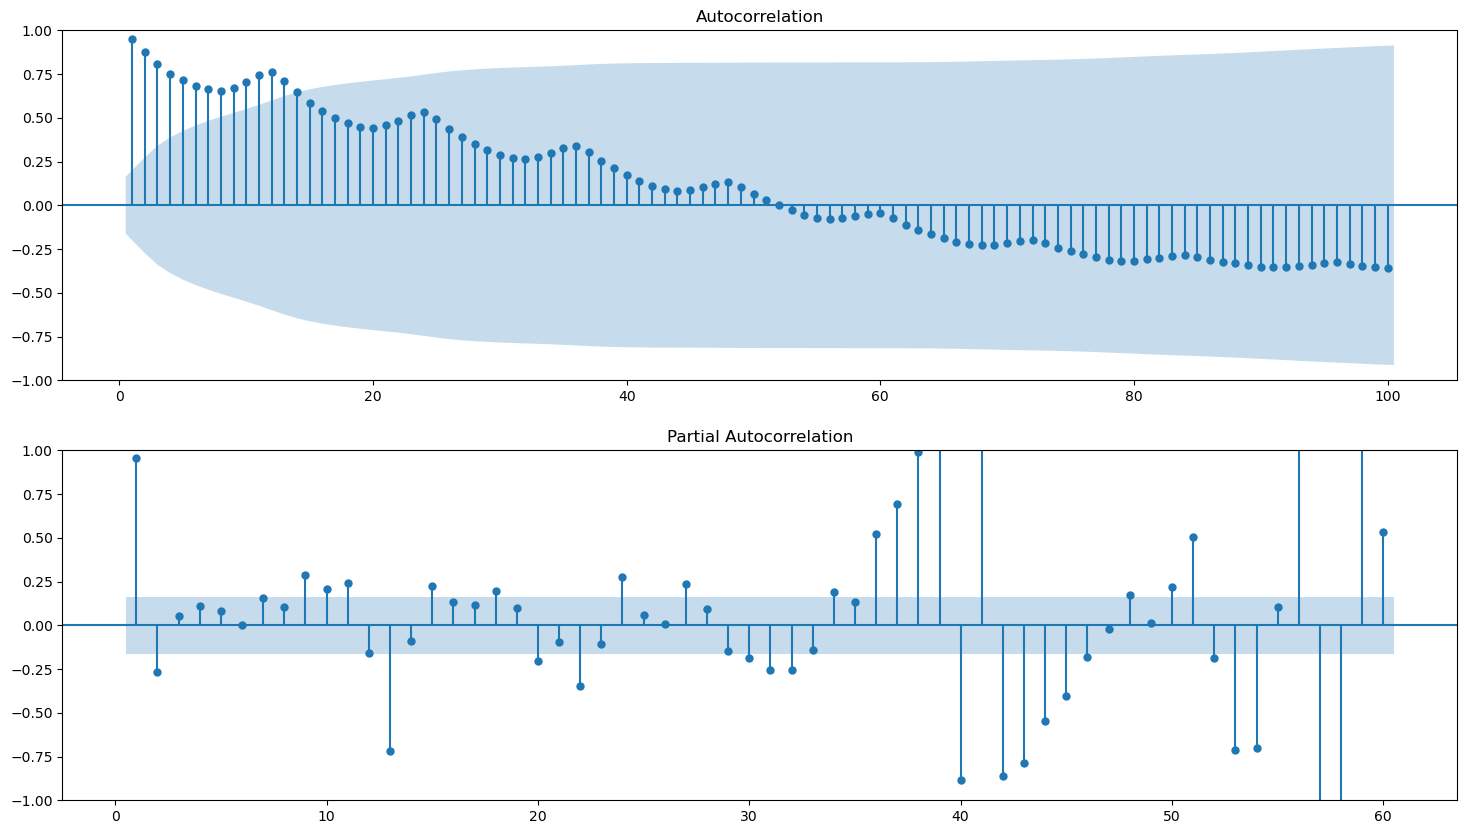

In [10]:
f, ax = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
plot_acf(df['value'],lags=100, ax=ax[0],zero=False)
plot_pacf(df['value'],lags=60, ax=ax[1],zero=False)
plt.show()

* Order (p,d,q) = (2,1,0)

# ARIMA MODEL - Manual 

from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
model = ARIMA(df.value,
                      start_p=0,max_p=3, # Pacf(p) = 0,1,2,3
                      d=0,max_d=2,       # Difference (d) = 0,1,2
                      start_q=0,max_q=3, # acf (q) = 0,1,2,3
                      m=12,              # frequency of series
                      seasonal=False,    # No Seasonality  then below P,D,Q will not be used 
                      start_P=0,max_P=2,
                      D=0,max_D=1,
                      start_Q=0,max_Q=2,
                      test='adf',       # use adftest to find optimal 'd'
                      trace=True)

# ARIMA MODEL -- Auto ( Grid Search )

In [22]:
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
model = pm.auto_arima(df.value,
                      start_p=0,max_p=3, # Pacf(p) = 0,1,2,3
                      d=0,max_d=2,       # Difference (d) = 0,1,2
                      start_q=0,max_q=3, # acf (q) = 0,1,2,3
                      m=12,              # frequency of series
                      seasonal=False,    # No Seasonality  then below P,D,Q will not be used 
                      test='adf',       # use adftest to find optimal 'd'
                      trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2057.847, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1412.973, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1410.569, Time=0.14 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1417.450, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1411.319, Time=0.20 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1411.135, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1413.093, Time=0.11 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.21 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.36 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1408.249, Time=0.29 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1409.748, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1413.639, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1408.287, T

# Fitted Value

In [12]:
import numpy as np
df['Forecast']=np.round(model.predict_in_sample(),0)
df.iloc[:,[0,1,4]]

,date,value,Forecast
0,1949-01-01,112,282.0
1,1949-02-01,118,118.0
2,1949-03-01,132,127.0
3,1949-04-01,129,140.0
4,1949-05-01,121,132.0
...,...,...,...
139,1960-08-01,606,618.0
140,1960-09-01,508,580.0
141,1960-10-01,461,473.0
142,1960-11-01,390,459.0


# Model plot

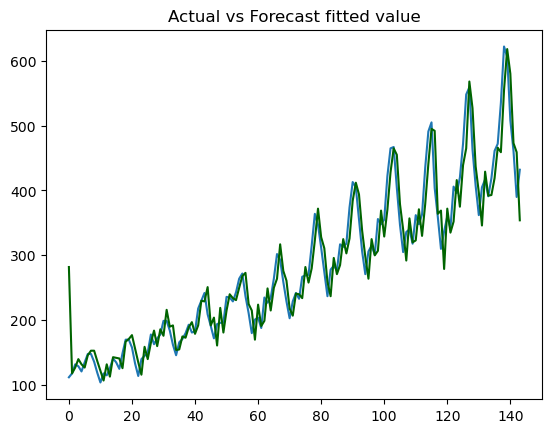

In [13]:
# Plot
plt.plot(df.value)
plt.plot(df.Forecast, color='darkgreen')
plt.title("Actual vs Forecast fitted value")
plt.show()

# Accuracy metrics


In [14]:
def forecast_accuracy(actual,forecast):
    mape = (np.mean(np.abs(actual-forecast)/np.abs(actual)))*100  # MAPE
    return({'mape':mape})

forecast_accuracy(df.value,df.Forecast)

{'mape': 9.551601916121353}

#  Forecast - Future Month


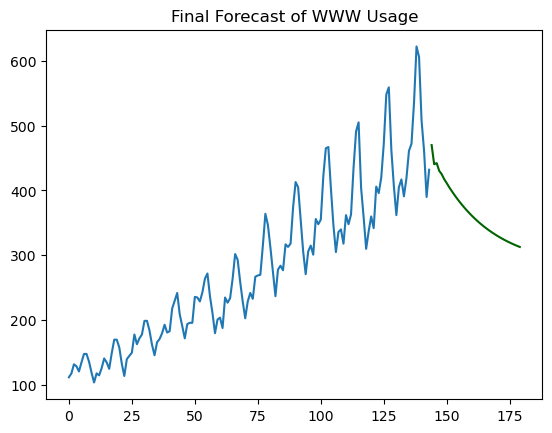

In [15]:
n_periods=36
fc = model.predict(n_periods=n_periods)
index_of_fc = np.arange(len(df.value), len(df.value)+n_periods)

# make series for plotting purpose
fc_series = pd.Series(fc, index=index_of_fc)

# Plot
plt.plot(df.value)
plt.plot(fc_series, color='darkgreen')
plt.title("Final Forecast of WWW Usage")
plt.show()

In [ ]:
fc

# SARIMAX -- Auto ( Grid Search )

In [16]:
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
smodel = pm.auto_arima(df.value,
                      start_p=0,max_p=3, # Pacf(p) = 0,1,2,3
                      d=0,max_d=2,       # Difference (d) = 0,1,2
                      start_q=0,max_q=3, # acf (q) = 0,1,2,3
                      m=12,              # frequency of series or time
                      seasonal=True,     # Seasonality is True then below P,D,Q will be used 
                      start_P=0,max_P=2, # P= 0,1,2
                      D=0,max_D=1,       # D = 0,1
                      start_Q=0,max_Q=2, # Q = 0,1,2
                      test='adf',       # use adftest to find optimal 'd'
                      trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1790.368, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2057.847, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1428.179, Time=0.05 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1315.686, Time=0.27 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1162.951, Time=0.35 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.98 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=1163.868, Time=0.86 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.86 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=1.13 s

# Fitted Value

In [17]:
df['S_Forecast']=smodel.predict_in_sample()
df.iloc[:,[0,1,5]]

,date,value,S_Forecast
0,1949-01-01,112,0.000000
1,1949-02-01,118,110.635337
2,1949-03-01,132,114.922624
3,1949-04-01,129,125.069985
4,1949-05-01,121,127.069307
...,...,...,...
139,1960-08-01,606,626.109057
140,1960-09-01,508,512.488150
141,1960-10-01,461,450.496694
142,1960-11-01,390,409.520637


# Model plot

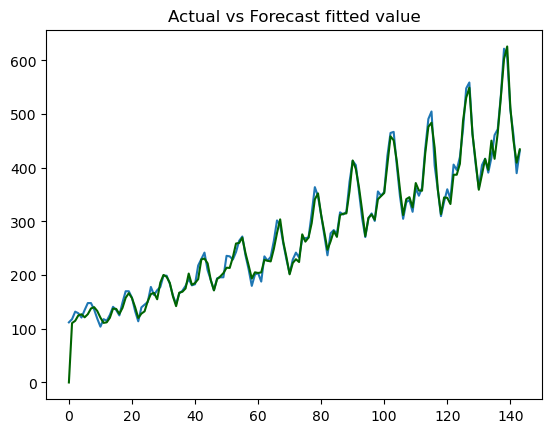

In [18]:
# Plot
plt.plot(df.value)
plt.plot(df.S_Forecast, color='darkgreen')
plt.title("Actual vs Forecast fitted value")
plt.show()

# Accuracy metrics


In [19]:
def forecast_accuracy(actual,forecast):
    mape = (np.mean(np.abs(actual-forecast)/np.abs(actual)))*100  # MAPE
    return({'mape':mape})

forecast_accuracy(df.value,df.S_Forecast)

{'mape': 4.1126398913083815}

#  Forecast


In [20]:
n_periods=36
future_Forecast = smodel.predict(n_periods=n_periods)
future_Forecast

144    443.957350
145    417.455589
146    452.883073
147    480.804719
148    495.141271
149    556.357273
150    640.718511
151    631.543765
152    528.777021
153    478.511077
154    412.183515
155    452.585984
156    464.705822
157    436.353153
158    469.706389
159    500.436286
160    514.888663
161    575.629227
162    661.950454
163    651.440924
164    545.903509
165    495.694586
166    427.437248
167    467.467520
168    479.286974
169    449.577594
170    480.764811
171    513.958795
172    528.456590
173    588.368988
174    675.955507
175    664.310851
176    556.961610
177    507.193890
178    437.646722
179    477.082122
dtype: float64

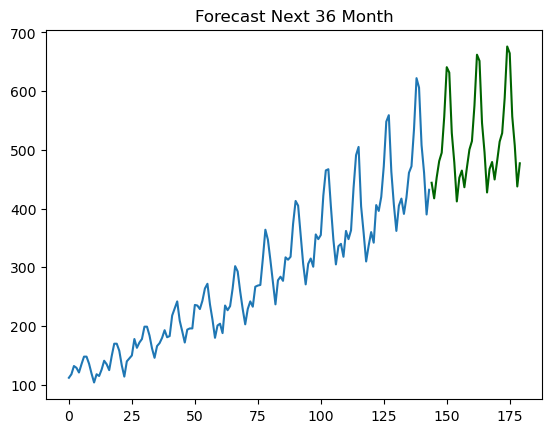

In [21]:
index_of_future_Forecast = np.arange(len(df.value), len(df.value)+n_periods)

# make series for plotting purpose
fc_series = pd.Series(future_Forecast, index=index_of_future_Forecast)

# Plot
plt.plot(df.value)
plt.plot(fc_series, color='darkgreen')
plt.title("Forecast Next 36 Month")
plt.show()

# Finished